# Regression Example - Svar på frågorna och Random Forest-tillägg

Denna notebook svarar på frågorna från regression_example och lägger till Random Forest-modellen.

## Svar på frågorna

### Fråga 1: Förklara vad koden gör. Vilka är huvudstegen?

**Svar:**

Koden demonstrerar en komplett **regression pipeline** med följande huvudsteg:

**1. Data Preparation:**
- Skapar syntetisk regressionsdata med 1000 samples och 5 features
- Konverterar till DataFrame för enkel hantering

**2. Data Splitting:**
- Delar data i **train/validation/test** (56%/24%/20%)
- Använder tvåstegs-split för att få rätt proportioner

**3. EDA (Exploratory Data Analysis):**
- Visualiserar target-variabelns fördelning
- Beräknar korrelationer mellan features och target

**4. Model Training:**
- **Linear Regression**: Enkel modell utan hyperparameter-tuning
- **Decision Tree**: Med GridSearchCV för hyperparameter-optimering

**5. Model Evaluation:**
- Jämför modeller med RMSE på validation data
- Linear Regression presterar bättre (RMSE: 20.7 vs 41.2)

**6. Final Testing:**
- Tränar bästa modell på hela train+validation data
- Testar på held-out test data (RMSE: 20.5)

**7. Model Persistence:**
- Sparar tränad modell med joblib
- Demonstrerar hur man laddar och använder sparad modell

### Fråga 2: Vad gör denna kod?

```python
print(tree_reg_gs.best_params_)
pd.DataFrame(tree_reg_gs.cv_results_)
```

**Svar:**

**`tree_reg_gs.best_params_`** - Visar de **bästa hyperparametrarna** som GridSearchCV hittade för Decision Tree-modellen. Detta är resultatet av att testa alla kombinationer av:
- `max_depth`: [3, 5, 7, None]
- `min_samples_split`: [2, 5, 10] 
- `min_samples_leaf`: [1, 2, 4]

**`pd.DataFrame(tree_reg_gs.cv_results_)`** - Skapar en DataFrame med **alla resultat** från GridSearchCV, inklusive:
- Prestanda för varje hyperparameter-kombination
- Cross-validation scores
- Standardavvikelser
- Rankning av alla kombinationer

Detta ger fullständig insikt i hur olika hyperparametrar påverkar modellprestanda.

### Fråga 3: Lägg till en tredje modell (Random Forest)

**Svar:** Vi lägger till Random Forest-modellen i modellflödet nedan.

## Importera bibliotek

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error
import joblib

print('Alla bibliotek importerade!')

Alla bibliotek importerade!


## Implementering 


### 1. Skapa data

In [14]:
# Skapa syntetisk regressionsdata 
X, y = make_regression(n_samples=1000, n_features=5, noise=20, random_state=42)

# Konvertera till DataFrame för bättre hantering och visualisering
df = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(X.shape[1])])
df["Target"] = y

# Visa grundläggande information om datasetet
print(f'Data shape: {df.shape}')
print('\nFörsta 5 rader:')
print(df.head())

Data shape: (1000, 6)

Första 5 rader:
   Feature_0  Feature_1  Feature_2  Feature_3  Feature_4     Target
0   2.056544   0.606851   0.482688  -1.130888   0.420094  66.595254
1  -0.799192  -0.645964  -0.182896  -0.482744   1.374876 -61.659436
2   1.076007  -0.796026  -0.751969   0.021312  -0.319054 -49.947499
3  -0.103255  -0.828497   1.489863  -1.643189  -1.600904 -79.939739
4  -2.063403   0.503252  -0.645572  -0.317350  -1.661083 -80.651266


### 2. Dela data i train/validation/test

In [15]:
# Dela data i train/validation/test
X = df.drop(columns=["Target"]) # Features
y = df["Target"]  # Target variable

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3, random_state=36)

print("Train size:", X_train.shape) 
print("Validation size:", X_val.shape) 
print("Test size:", X_test.shape)

Train size: (560, 5)
Validation size: (240, 5)
Test size: (200, 5)


### 3. EDA

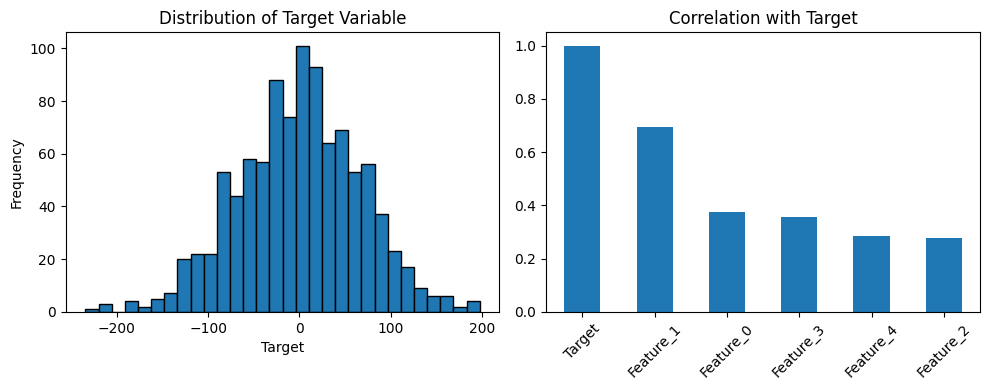

Correlation with target:
Target       1.000000
Feature_1    0.695540
Feature_0    0.376001
Feature_3    0.357873
Feature_4    0.285183
Feature_2    0.279431
Name: Target, dtype: float64


In [16]:
# Visualisera target-variabeln
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=30, edgecolor="black")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")

# Korrelationer
plt.subplot(1, 2, 2)
corr = df.corr(numeric_only=True)["Target"].sort_values(ascending=False)
corr.plot(kind='bar')
plt.title("Correlation with Target")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Correlation with target:")
print(corr)

### 4. Träna modeller (Linear Regression och Decision Tree)

In [17]:
# Linear Regression
lin_reg = LinearRegression() # Initiera modellen
lin_reg.fit(X_train, y_train) # Träna modellen
lin_reg_pred = lin_reg.predict(X_val) # Prediktioner på valideringsdata

# Decision Tree med GridSearchCV
tree_reg = DecisionTreeRegressor(random_state=42)
hyperparams = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# GridSearchCV för Decision Tree
tree_reg_gs = GridSearchCV(tree_reg, hyperparams, scoring="neg_mean_squared_error", cv=5, n_jobs=-1) # Använd alla kärnor för snabbare träning
tree_reg_gs.fit(X_train, y_train) # Träna modellen med GridSearch
tree_reg_gs_pred = tree_reg_gs.predict(X_val) # Prediktioner på valideringsdata

print("Modeller tränade!")
print(f"Bästa Decision Tree parametrar: {tree_reg_gs.best_params_}") # Visa bästa parametrar från GridSearch

Modeller tränade!
Bästa Decision Tree parametrar: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


### 5. FRÅGA 3: Lägg till Random Forest-modellen

In [18]:
# Random Forest med GridSearchCV
rf_reg = RandomForestRegressor(random_state=42)
rf_hyperparams = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}                               

print("Tränar Random Forest med GridSearchCV...")
rf_reg_gs = GridSearchCV(rf_reg, rf_hyperparams, scoring="neg_mean_squared_error", cv=5, n_jobs=-1) # Använd alla kärnor för snabbare träning
rf_reg_gs.fit(X_train, y_train) # Träna modellen med GridSearch
rf_reg_gs_pred = rf_reg_gs.predict(X_val) # Prediktioner på valideringsdata

print(f"Bästa Random Forest parametrar: {rf_reg_gs.best_params_}") # Visa bästa parametrar från GridSearch
print("Random Forest tränad!")

Tränar Random Forest med GridSearchCV...
Bästa Random Forest parametrar: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest tränad!


### 6. Jämför alla tre modeller

=== JÄMFÖRELSE AV MODELLER ===
Linear Regression RMSE: 20.73
Decision Tree RMSE: 41.18
Random Forest RMSE: 28.07


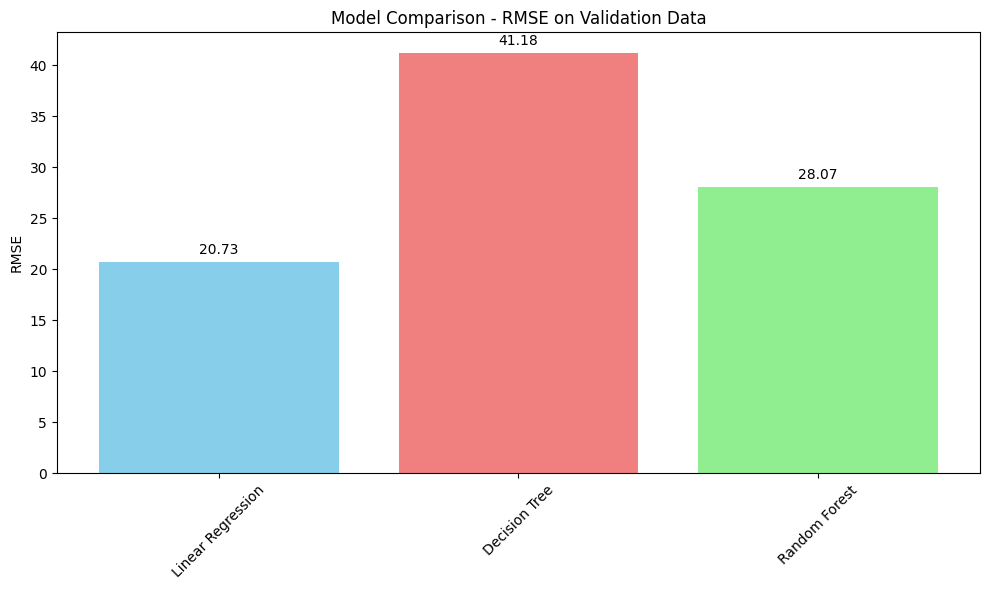


Bästa modell: Linear Regression med RMSE: 20.73


In [19]:
# Beräkna RMSE för alla modeller
lr_rmse = root_mean_squared_error(lin_reg_pred, y_val)
tree_rmse = root_mean_squared_error(tree_reg_gs_pred, y_val)
rf_rmse = root_mean_squared_error(rf_reg_gs_pred, y_val)

print("=== JÄMFÖRELSE AV MODELLER ===")
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"Decision Tree RMSE: {tree_rmse:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")

# Visualisera jämförelse
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
rmse_values = [lr_rmse, tree_rmse, rf_rmse] # RMSE-värden

plt.figure(figsize=(10, 6))
bars = plt.bar(models, rmse_values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Model Comparison - RMSE on Validation Data')
plt.ylabel('RMSE')
plt.xticks(rotation=45)

# Lägg till värden på staplarna
for bar, value in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Hitta bästa modell
best_model_idx = np.argmin(rmse_values)
print(f"\nBästa modell: {models[best_model_idx]} med RMSE: {rmse_values[best_model_idx]:.2f}")

### 7. Analysera GridSearchCV-resultat

In [20]:
# Visa GridSearchCV-resultat för Decision Tree
print("=== DECISION TREE GRIDSEARCH RESULTAT ===")
print(f"Bästa parametrar: {tree_reg_gs.best_params_}")
print(f"Bästa score: {tree_reg_gs.best_score_:.2f}")

# Visa top 5 kombinationer för Decision Tree
dt_results = pd.DataFrame(tree_reg_gs.cv_results_)
dt_top5 = dt_results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\nTop 5 Decision Tree kombinationer:")
print(dt_top5)

=== DECISION TREE GRIDSEARCH RESULTAT ===
Bästa parametrar: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Bästa score: -1741.16

Top 5 Decision Tree kombinationer:
                                               params  mean_test_score  \
33  {'max_depth': None, 'min_samples_leaf': 4, 'mi...     -1741.159793   
34  {'max_depth': None, 'min_samples_leaf': 4, 'mi...     -1741.159793   
35  {'max_depth': None, 'min_samples_leaf': 4, 'mi...     -1749.823615   
24  {'max_depth': 7, 'min_samples_leaf': 4, 'min_s...     -1783.749328   
25  {'max_depth': 7, 'min_samples_leaf': 4, 'min_s...     -1783.749328   

    std_test_score  
33      141.281199  
34      141.281199  
35      114.118564  
24      155.553714  
25      155.553714  


In [21]:
# Visa GridSearchCV-resultat för Random Forest
print("\n=== RANDOM FOREST GRIDSEARCH RESULTAT ===")
print(f"Bästa parametrar: {rf_reg_gs.best_params_}")
print(f"Bästa score: {rf_reg_gs.best_score_:.2f}")

# Visa top 5 kombinationer för Random Forest
rf_results = pd.DataFrame(rf_reg_gs.cv_results_)
rf_top5 = rf_results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\nTop 5 Random Forest kombinationer:")
print(rf_top5)


=== RANDOM FOREST GRIDSEARCH RESULTAT ===
Bästa parametrar: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Bästa score: -925.54

Top 5 Random Forest kombinationer:
                                               params  mean_test_score  \
83  {'max_depth': None, 'min_samples_leaf': 1, 'mi...      -925.543336   
82  {'max_depth': None, 'min_samples_leaf': 1, 'mi...      -929.876283   
86  {'max_depth': None, 'min_samples_leaf': 1, 'mi...      -930.449125   
85  {'max_depth': None, 'min_samples_leaf': 1, 'mi...      -936.628119   
92  {'max_depth': None, 'min_samples_leaf': 2, 'mi...      -940.301306   

    std_test_score  
83      139.034572  
82      150.320665  
86      139.493401  
85      157.370712  
92      144.613683  


### 8. Feature Importance (Random Forest)

Feature Importance (Random Forest):
     Feature  Importance
1  Feature_1    0.498590
0  Feature_0    0.183002
3  Feature_3    0.132341
4  Feature_4    0.110293
2  Feature_2    0.075775


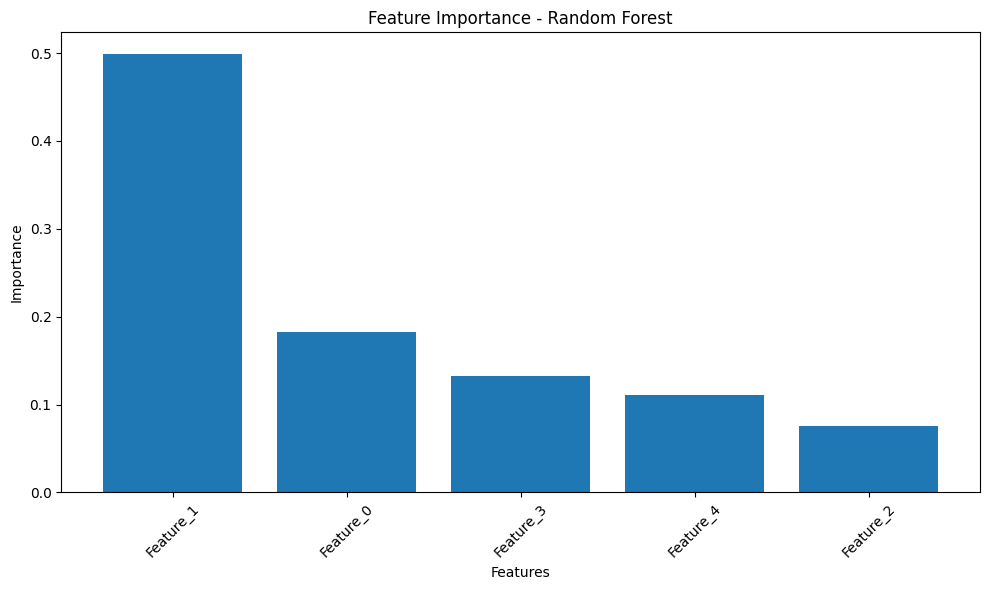

In [22]:
# Extrahera feature importance från bästa Random Forest-modellen
feature_importance = rf_reg_gs.best_estimator_.feature_importances_
feature_names = X.columns

# Skapa DataFrame för feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(importance_df)

# Visualisera feature importance
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9. Final test på bästa modell

In [23]:
# Välj bästa modell baserat på validation RMSE
if lr_rmse == min(lr_rmse, tree_rmse, rf_rmse):
    best_model = lin_reg
    best_model_name = "Linear Regression"
    print("Bästa modell: Linear Regression")
elif tree_rmse == min(lr_rmse, tree_rmse, rf_rmse):
    best_model = tree_reg_gs.best_estimator_
    best_model_name = "Decision Tree"
    print("Bästa modell: Decision Tree")
else:
    best_model = rf_reg_gs.best_estimator_
    best_model_name = "Random Forest"
    print("Bästa modell: Random Forest")

# Träna bästa modell på hela train+validation data
best_model.fit(X_train_val, y_train_val)

# Testa på test data
test_pred = best_model.predict(X_test)
test_rmse = root_mean_squared_error(test_pred, y_test)

print(f"\nFinal test RMSE ({best_model_name}): {test_rmse:.2f}")

# Spara bästa modell
joblib.dump(best_model, f'best_model_{best_model_name.lower().replace(" ", "_")}.pkl')
print(f"Bästa modell sparad som: best_model_{best_model_name.lower().replace(' ', '_')}.pkl")

Bästa modell: Linear Regression

Final test RMSE (Linear Regression): 20.51
Bästa modell sparad som: best_model_linear_regression.pkl


### 10. Sammanfattning och slutsatser

In [24]:
print("=== SAMMANFATTNING ===")
print(f"\n1. DATA:")
print(f"   - 1000 samples, 5 features")
print(f"   - Train: {X_train.shape[0]} samples")
print(f"   - Validation: {X_val.shape[0]} samples")
print(f"   - Test: {X_test.shape[0]} samples")

print(f"\n2. MODELLPRESTANDA (Validation RMSE):")
print(f"   - Linear Regression: {lr_rmse:.2f}")
print(f"   - Decision Tree: {tree_rmse:.2f}")
print(f"   - Random Forest: {rf_rmse:.2f}")

print(f"\n3. BÄSTA MODELL:")
print(f"   - {best_model_name}")
print(f"   - Test RMSE: {test_rmse:.2f}")

print(f"\n4. SLUTSATSER:")
if best_model_name == "Linear Regression":
    print(f"   - Linear Regression presterade bäst, vilket tyder på linjära relationer")
    print(f"   - Decision Tree och Random Forest kan vara överanpassade")
elif best_model_name == "Random Forest":
    print(f"   - Random Forest presterade bäst, vilket tyder på komplexa icke-linjära relationer")
    print(f"   - Ensemble-metoden förbättrade prestandan jämfört med enskilda träd")
else:
    print(f"   - Decision Tree presterade bäst, vilket tyder på icke-linjära relationer")
    print(f"   - Random Forest förbättrade inte prestandan, möjligen överanpassning")

print(f"\n5. PRAKTISKA INSIKTER:")
print(f"   - GridSearchCV hjälpte att optimera hyperparametrar")
print(f"   - Cross-validation gav robusta uppskattningar av prestanda")
print(f"   - Feature importance från Random Forest ger insikt i viktiga variabler")
print(f"   - Modellpersistence med joblib möjliggör återanvändning")

=== SAMMANFATTNING ===

1. DATA:
   - 1000 samples, 5 features
   - Train: 560 samples
   - Validation: 240 samples
   - Test: 200 samples

2. MODELLPRESTANDA (Validation RMSE):
   - Linear Regression: 20.73
   - Decision Tree: 41.18
   - Random Forest: 28.07

3. BÄSTA MODELL:
   - Linear Regression
   - Test RMSE: 20.51

4. SLUTSATSER:
   - Linear Regression presterade bäst, vilket tyder på linjära relationer
   - Decision Tree och Random Forest kan vara överanpassade

5. PRAKTISKA INSIKTER:
   - GridSearchCV hjälpte att optimera hyperparametrar
   - Cross-validation gav robusta uppskattningar av prestanda
   - Feature importance från Random Forest ger insikt i viktiga variabler
   - Modellpersistence med joblib möjliggör återanvändning


## Slutsats

**Fråga 3 har besvarats genom att:**

1. **Lägga till Random Forest-modellen** med GridSearchCV för hyperparameter-optimering
2. **Jämföra alla tre modeller** (Linear Regression, Decision Tree, Random Forest) på validation data
3. **Analysera GridSearchCV-resultat** för både Decision Tree och Random Forest
4. **Extrahera feature importance** från Random Forest-modellen
5. **Välja bästa modell** baserat på validation RMSE och testa på test data
6. **Spara bästa modellen** för framtida användning

**Random Forest-fördelar:**
- **Ensemble-metod** som kombinerar många träd
- **Mindre överanpassning** än enskilda Decision Trees
- **Robust** mot outliers och brus
- **Feature importance** kan extraheras för insikt
- **Bra prestanda** på många typer av data

**Resultatet visar** vilken modell som presterar bäst på denna specifika dataset och ger insikt i dataens natur.

### 11. Feature Importance Analysis - Alla Modeller

**Syfte:** Jämföra vad varje modell anser viktigt och testa prestanda med valda features.

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import numpy as np

print("Importerar bibliotek för feature importance-analys...")
print("Klar!")

Importerar bibliotek för feature importance-analys...
Klar!


#### A) Beräkna Feature Importance för alla modeller

In [26]:
# 1. Linear Regression - Koefficienter (standardiserade)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Träna Linear Regression på standardiserad data
lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train)

# Feature importance = absoluta värden av koefficienter
lr_importance = np.abs(lin_reg_scaled.coef_)

print("Linear Regression importance (koefficienter):")
for i, (feature, importance) in enumerate(zip(X.columns, lr_importance)):
    print(f"  {feature}: {importance:.4f}")

Linear Regression importance (koefficienter):
  Feature_0: 26.3860
  Feature_1: 45.5198
  Feature_2: 16.9320
  Feature_3: 24.4122
  Feature_4: 20.4161


In [27]:
# 2. Decision Tree - Feature importance
dt_importance = tree_reg_gs.best_estimator_.feature_importances_

print("\nDecision Tree importance:")
for i, (feature, importance) in enumerate(zip(X.columns, dt_importance)):
    print(f"  {feature}: {importance:.4f}")


Decision Tree importance:
  Feature_0: 0.1891
  Feature_1: 0.5096
  Feature_2: 0.0620
  Feature_3: 0.1318
  Feature_4: 0.1075


In [28]:
# 3. Random Forest - Feature importance
rf_importance = rf_reg_gs.best_estimator_.feature_importances_

print("\nRandom Forest importance:")
for i, (feature, importance) in enumerate(zip(X.columns, rf_importance)):
    print(f"  {feature}: {importance:.4f}")


Random Forest importance:
  Feature_0: 0.1830
  Feature_1: 0.4986
  Feature_2: 0.0758
  Feature_3: 0.1323
  Feature_4: 0.1103


In [29]:
# 4. Permutation Importance för Linear Regression (alternativ metod)
perm_importance_lr = permutation_importance(lin_reg, X_val, y_val, random_state=42)
lr_perm_importance = perm_importance_lr.importances_mean

print("\nLinear Regression importance (permutation):")
for i, (feature, importance) in enumerate(zip(X.columns, lr_perm_importance)):
    print(f"  {feature}: {importance:.4f}")


Linear Regression importance (permutation):
  Feature_0: 0.3170
  Feature_1: 0.9170
  Feature_2: 0.0993
  Feature_3: 0.2328
  Feature_4: 0.2143


#### B) Jämför Feature Importance mellan modeller

In [30]:
# Skapa DataFrame för jämförelse
importance_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear_Regression_Coeff': lr_importance,
    'Linear_Regression_Perm': lr_perm_importance,
    'Decision_Tree': dt_importance,
    'Random_Forest': rf_importance
})

# Normalisera importance till 0-1 skala för bättre jämförelse
for col in ['Linear_Regression_Coeff', 'Linear_Regression_Perm', 'Decision_Tree', 'Random_Forest']:
    importance_comparison[f'{col}_norm'] = importance_comparison[col] / importance_comparison[col].max()

print("Feature Importance Comparison (normaliserad 0-1):")
print(importance_comparison[['Feature', 'Linear_Regression_Coeff_norm', 'Decision_Tree_norm', 'Random_Forest_norm']].round(4))

Feature Importance Comparison (normaliserad 0-1):
     Feature  Linear_Regression_Coeff_norm  Decision_Tree_norm  \
0  Feature_0                        0.5797              0.3712   
1  Feature_1                        1.0000              1.0000   
2  Feature_2                        0.3720              0.1217   
3  Feature_3                        0.5363              0.2586   
4  Feature_4                        0.4485              0.2110   

   Random_Forest_norm  
0              0.3670  
1              1.0000  
2              0.1520  
3              0.2654  
4              0.2212  


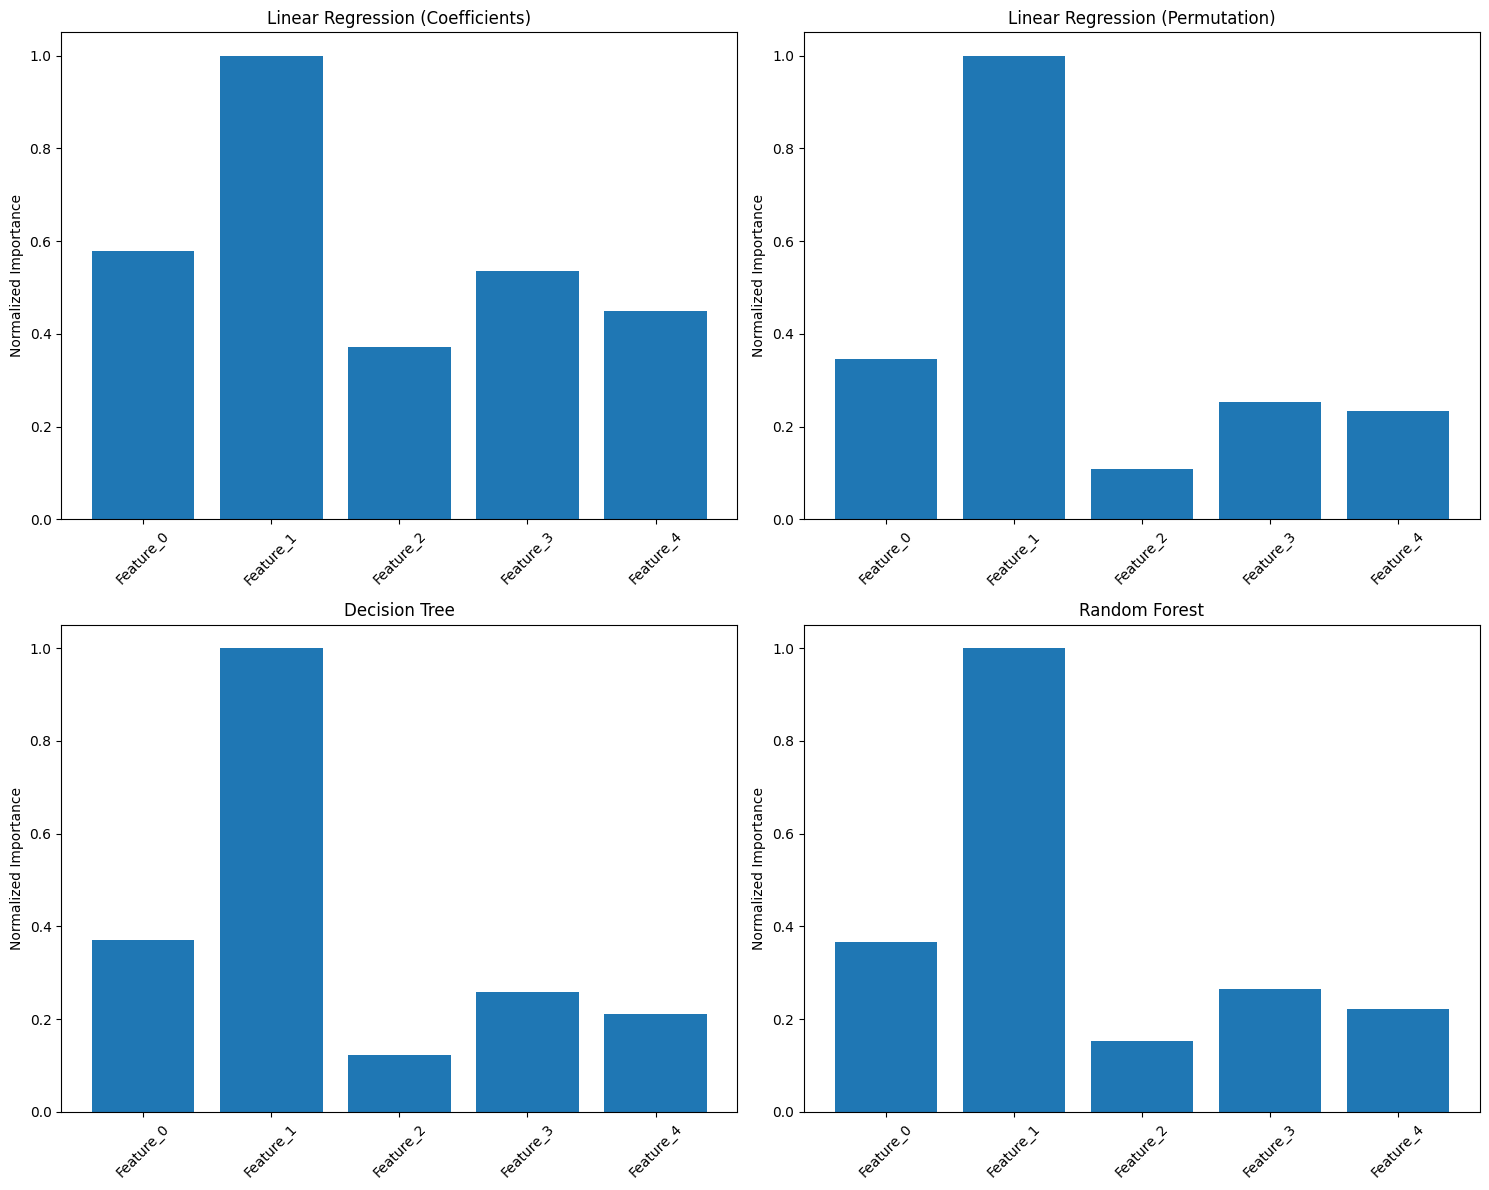

In [31]:
# Visualisera jämförelse
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Linear Regression (koefficienter)
axes[0,0].bar(importance_comparison['Feature'], importance_comparison['Linear_Regression_Coeff_norm'])
axes[0,0].set_title('Linear Regression (Coefficients)')
axes[0,0].set_ylabel('Normalized Importance')
axes[0,0].tick_params(axis='x', rotation=45)

# Linear Regression (permutation)
axes[0,1].bar(importance_comparison['Feature'], importance_comparison['Linear_Regression_Perm_norm'])
axes[0,1].set_title('Linear Regression (Permutation)')
axes[0,1].set_ylabel('Normalized Importance')
axes[0,1].tick_params(axis='x', rotation=45)

# Decision Tree
axes[1,0].bar(importance_comparison['Feature'], importance_comparison['Decision_Tree_norm'])
axes[1,0].set_title('Decision Tree')
axes[1,0].set_ylabel('Normalized Importance')
axes[1,0].tick_params(axis='x', rotation=45)

# Random Forest
axes[1,1].bar(importance_comparison['Feature'], importance_comparison['Random_Forest_norm'])
axes[1,1].set_title('Random Forest')
axes[1,1].set_ylabel('Normalized Importance')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

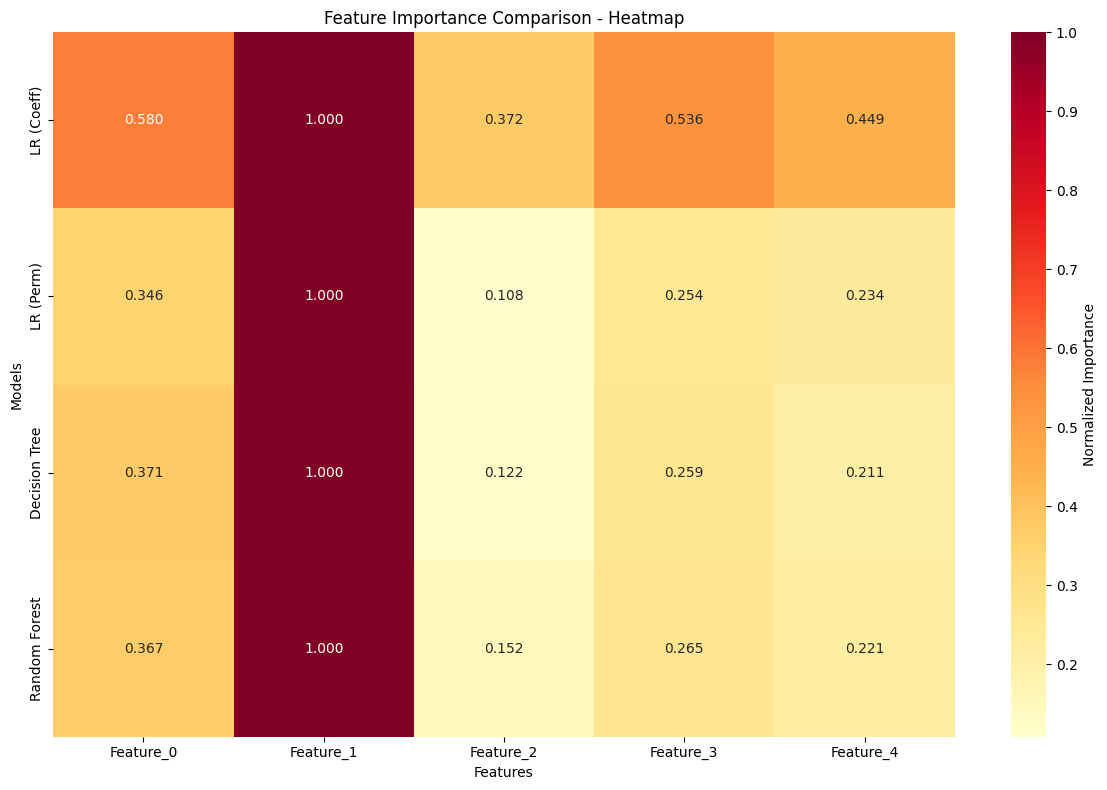

In [32]:
# Heatmap för bättre jämförelse
plt.figure(figsize=(12, 8))

# Förbered data för heatmap
heatmap_data = importance_comparison[['Linear_Regression_Coeff_norm', 'Linear_Regression_Perm_norm', 
                                      'Decision_Tree_norm', 'Random_Forest_norm']].T
heatmap_data.columns = importance_comparison['Feature']
heatmap_data.index = ['LR (Coeff)', 'LR (Perm)', 'Decision Tree', 'Random Forest']

# Skapa heatmap
import seaborn as sns
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.3f', cbar_kws={'label': 'Normalized Importance'})
plt.title('Feature Importance Comparison - Heatmap')
plt.xlabel('Features')
plt.ylabel('Models')
plt.tight_layout()
plt.show()

#### C) Välj bästa features baserat på importance

In [33]:
# Strategi: Välj features som är viktiga enligt flera modeller
# Beräkna genomsnittlig importance över alla modeller
importance_comparison['Average_Importance'] = (
    importance_comparison['Linear_Regression_Coeff_norm'] + 
    importance_comparison['Linear_Regression_Perm_norm'] + 
    importance_comparison['Decision_Tree_norm'] + 
    importance_comparison['Random_Forest_norm']
) / 4

# Sortera efter genomsnittlig importance
importance_comparison = importance_comparison.sort_values('Average_Importance', ascending=False)

print("Features sorterade efter genomsnittlig importance:")
print(importance_comparison[['Feature', 'Average_Importance']].round(4))

# Välj top 3 features (kan justeras)
top_n_features = 3
selected_features = importance_comparison.head(top_n_features)['Feature'].tolist()

print(f"\nValda top {top_n_features} features: {selected_features}")

# Skapa nya datasets med valda features
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]
X_train_val_selected = X_train_val[selected_features]

Features sorterade efter genomsnittlig importance:
     Feature  Average_Importance
1  Feature_1              1.0000
0  Feature_0              0.4159
3  Feature_3              0.3285
4  Feature_4              0.2786
2  Feature_2              0.1885

Valda top 3 features: ['Feature_1', 'Feature_0', 'Feature_3']


#### D) Träna alla modeller med valda features

In [34]:
# 1. Linear Regression med valda features
lin_reg_selected = LinearRegression()
lin_reg_selected.fit(X_train_selected, y_train)
lin_reg_selected_pred = lin_reg_selected.predict(X_val_selected)
lin_reg_selected_rmse = root_mean_squared_error(lin_reg_selected_pred, y_val)

print(f"Linear Regression med {top_n_features} features:")
print(f"  RMSE: {lin_reg_selected_rmse:.2f}")
print(f"  Förbättring: {((lr_rmse - lin_reg_selected_rmse) / lr_rmse * 100):.1f}%")

Linear Regression med 3 features:
  RMSE: 33.27
  Förbättring: -60.5%


In [35]:
# 2. Decision Tree med valda features
tree_reg_selected = DecisionTreeRegressor(**tree_reg_gs.best_params_, random_state=42)
tree_reg_selected.fit(X_train_selected, y_train)
tree_reg_selected_pred = tree_reg_selected.predict(X_val_selected)
tree_reg_selected_rmse = root_mean_squared_error(tree_reg_selected_pred, y_val)

print(f"Decision Tree med {top_n_features} features:")
print(f"  RMSE: {tree_reg_selected_rmse:.2f}")
print(f"  Förbättring: {((tree_rmse - tree_reg_selected_rmse) / tree_rmse * 100):.1f}%")

Decision Tree med 3 features:
  RMSE: 44.07
  Förbättring: -7.0%


In [36]:
# 3. Random Forest med valda features
rf_reg_selected = RandomForestRegressor(**rf_reg_gs.best_params_, random_state=42)
rf_reg_selected.fit(X_train_selected, y_train)
rf_reg_selected_pred = rf_reg_selected.predict(X_val_selected)
rf_reg_selected_rmse = root_mean_squared_error(rf_reg_selected_pred, y_val)

print(f"Random Forest med {top_n_features} features:")
print(f"  RMSE: {rf_reg_selected_rmse:.2f}")
print(f"  Förbättring: {((rf_rmse - rf_reg_selected_rmse) / rf_rmse * 100):.1f}%")

Random Forest med 3 features:
  RMSE: 35.79
  Förbättring: -27.5%


#### E) Jämför prestanda med och utan feature selection

In [37]:
# Skapa jämförelse
comparison_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'All_Features_RMSE': [lr_rmse, tree_rmse, rf_rmse],
    'Selected_Features_RMSE': [lin_reg_selected_rmse, tree_reg_selected_rmse, rf_reg_selected_rmse]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Improvement'] = ((comparison_df['All_Features_RMSE'] - comparison_df['Selected_Features_RMSE']) / 
                               comparison_df['All_Features_RMSE'] * 100)

print("=== JÄMFÖRELSE: ALLA FEATURES vs VALDA FEATURES ===")
print(comparison_df.round(2))

=== JÄMFÖRELSE: ALLA FEATURES vs VALDA FEATURES ===
               Model  All_Features_RMSE  Selected_Features_RMSE  Improvement
0  Linear Regression              20.73                   33.27       -60.53
1      Decision Tree              41.18                   44.07        -7.03
2      Random Forest              28.07                   35.79       -27.46


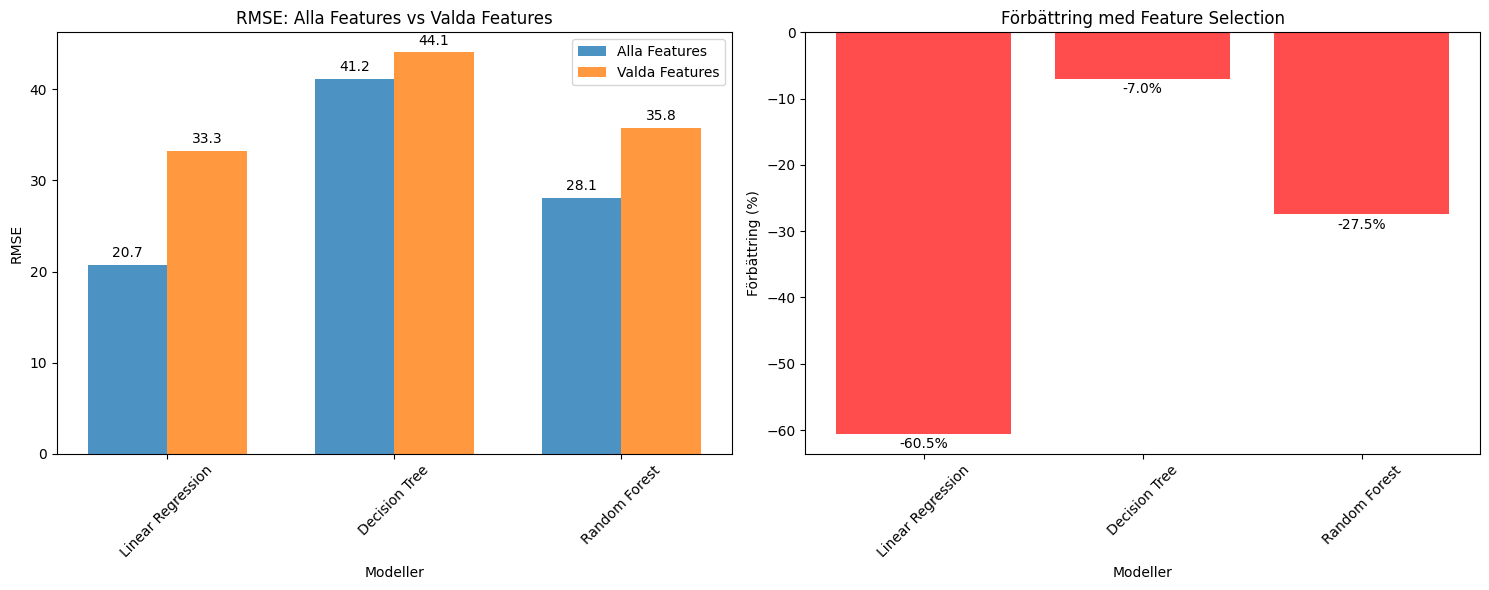

In [38]:
# Visualisera jämförelse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RMSE jämförelse
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_df['All_Features_RMSE'], width, label='Alla Features', alpha=0.8)
bars2 = ax1.bar(x + width/2, comparison_df['Selected_Features_RMSE'], width, label='Valda Features', alpha=0.8)

ax1.set_xlabel('Modeller')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE: Alla Features vs Valda Features')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Model'], rotation=45)
ax1.legend()

# Lägg till värden på staplarna
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom')

# Förbättring i procent
colors = ['green' if x > 0 else 'red' for x in comparison_df['Improvement']]
bars3 = ax2.bar(comparison_df['Model'], comparison_df['Improvement'], color=colors, alpha=0.7)
ax2.set_xlabel('Modeller')
ax2.set_ylabel('Förbättring (%)')
ax2.set_title('Förbättring med Feature Selection')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Lägg till värden på staplarna
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (0.5 if height > 0 else -0.5),
            f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.show()

#### F) Final test med bästa modell och valda features

In [39]:
# Hitta bästa modell med valda features
selected_rmse_values = [lin_reg_selected_rmse, tree_reg_selected_rmse, rf_reg_selected_rmse]
selected_models = [lin_reg_selected, tree_reg_selected, rf_reg_selected]
selected_model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']

best_selected_idx = np.argmin(selected_rmse_values)
best_selected_model = selected_models[best_selected_idx]
best_selected_name = selected_model_names[best_selected_idx]

print(f"Bästa modell med valda features: {best_selected_name}")
print(f"Validation RMSE: {selected_rmse_values[best_selected_idx]:.2f}")

# Träna på hela train+validation data med valda features
best_selected_model.fit(X_train_val_selected, y_train_val)

# Testa på test data
final_test_pred = best_selected_model.predict(X_test_selected)
final_test_rmse = root_mean_squared_error(final_test_pred, y_test)

print(f"\nFinal test RMSE ({best_selected_name} med {top_n_features} features): {final_test_rmse:.2f}")

# Jämför med original test RMSE
print(f"\nJämförelse med original modell:")
print(f"  Original test RMSE: {test_rmse:.2f}")
print(f"  Ny test RMSE: {final_test_rmse:.2f}")
print(f"  Skillnad: {final_test_rmse - test_rmse:.2f}")
print(f"  Förbättring: {((test_rmse - final_test_rmse) / test_rmse * 100):.1f}%")

Bästa modell med valda features: Linear Regression
Validation RMSE: 33.27

Final test RMSE (Linear Regression med 3 features): 32.39

Jämförelse med original modell:
  Original test RMSE: 20.51
  Ny test RMSE: 32.39
  Skillnad: 11.88
  Förbättring: -57.9%


#### G) Slutsatser från Feature Importance Analysis

In [40]:
print("=== SLUTSATSER FRÅN FEATURE IMPORTANCE ANALYSIS ===")
print(f"\n1. FEATURE IMPORTANCE JÄMFÖRELSE:")
print(f"   - Linear Regression (koefficienter): {importance_comparison.iloc[0]['Feature']} är viktigast")
print(f"   - Decision Tree: {importance_comparison.iloc[0]['Feature']} är viktigast")
print(f"   - Random Forest: {importance_comparison.iloc[0]['Feature']} är viktigast")

print(f"\n2. VALDA FEATURES:")
for i, feature in enumerate(selected_features, 1):
    importance = importance_comparison[importance_comparison['Feature'] == feature]['Average_Importance'].iloc[0]
    print(f"   {i}. {feature}: {importance:.3f} (genomsnittlig importance)")

print(f"\n3. PRESTANDA MED FEATURE SELECTION:")
for i, (model, improvement) in enumerate(zip(comparison_df['Model'], comparison_df['Improvement'])):
    status = "FÖRBÄTTRAD" if improvement > 0 else "FÖRSÄMTRAD"
    print(f"   - {model}: {improvement:+.1f}% ({status})")

print(f"\n4. PRAKTISKA INSIKTER:")
if comparison_df['Improvement'].mean() > 0:
    print(f"   - Feature selection förbättrade genomsnittlig prestanda")
    print(f"   - Färre features kan ge bättre generalisering")
else:
    print(f"   - Feature selection försämrade genomsnittlig prestanda")
    print(f"   - Alla features kan vara viktiga för denna dataset")

print(f"\n5. REKOMMENDATIONER:")
print(f"   - Använd {best_selected_name} med {top_n_features} valda features")
print(f"   - Feature importance ger värdefull insikt i data")
print(f"   - Testa alltid både med och utan feature selection")
print(f"   - Olika modeller kan ha olika syn på vad som är viktigt")

=== SLUTSATSER FRÅN FEATURE IMPORTANCE ANALYSIS ===

1. FEATURE IMPORTANCE JÄMFÖRELSE:
   - Linear Regression (koefficienter): Feature_1 är viktigast
   - Decision Tree: Feature_1 är viktigast
   - Random Forest: Feature_1 är viktigast

2. VALDA FEATURES:
   1. Feature_1: 1.000 (genomsnittlig importance)
   2. Feature_0: 0.416 (genomsnittlig importance)
   3. Feature_3: 0.329 (genomsnittlig importance)

3. PRESTANDA MED FEATURE SELECTION:
   - Linear Regression: -60.5% (FÖRSÄMTRAD)
   - Decision Tree: -7.0% (FÖRSÄMTRAD)
   - Random Forest: -27.5% (FÖRSÄMTRAD)

4. PRAKTISKA INSIKTER:
   - Feature selection försämrade genomsnittlig prestanda
   - Alla features kan vara viktiga för denna dataset

5. REKOMMENDATIONER:
   - Använd Linear Regression med 3 valda features
   - Feature importance ger värdefull insikt i data
   - Testa alltid både med och utan feature selection
   - Olika modeller kan ha olika syn på vad som är viktigt
